In [ ]:
##Lab 10
##Joselin Rosiles Rivera

In [1]:
#Importar las librerias
#librerias para graficar
import matplotlib.pyplot as plt 
#librerias que permite trabajar con estructuras complejas, como Grafos
import networkx as nx

In [2]:
grafo = nx.DiGraph()
grafo.add_weighted_edges_from(
    [
        ("Centro", "Este",25),
        ("Centro", "Sur",15),
        ("Centro", "Norte",10),
        ("Norte", "Sur",30),
        ("Norte", "Este",8),
        ("Norte", "Oeste",15),
        ("Sur", "Oeste",9),
        ("Oeste", "Areopuerto",18),
         ("Este", "Areopuerto",20)
    ])

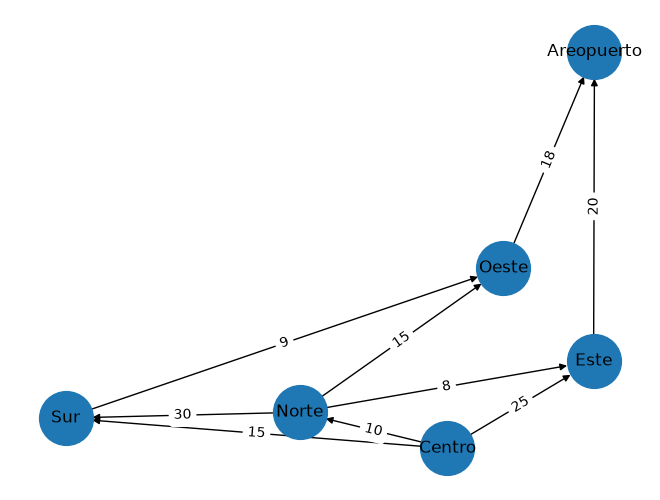

In [4]:
#Imprimimos el grafo
pos = nx.spring_layout( grafo, seed=9)
nx.draw(
    grafo,
    pos,
    with_labels=True,
    node_size=1500,
    arrows=True
)
labels =nx.get_edge_attributes (grafo, "weight")
nx.draw_networkx_edge_labels(
    grafo,
    pos,
    edge_labels=labels
)
plt.show()

In [5]:
#Mostramos las rutas
rutas=list(
    nx.all_simple_paths(
        grafo,
        source="Centro",
        target="Areopuerto"
    )
)

In [6]:
#Imprimimos las rutas
for i, ruta in enumerate (rutas,start=1):
    print (f"Ruta {i}:{ruta}")

Ruta 1:['Centro', 'Este', 'Areopuerto']
Ruta 2:['Centro', 'Sur', 'Oeste', 'Areopuerto']
Ruta 3:['Centro', 'Norte', 'Sur', 'Oeste', 'Areopuerto']
Ruta 4:['Centro', 'Norte', 'Este', 'Areopuerto']
Ruta 5:['Centro', 'Norte', 'Oeste', 'Areopuerto']


In [7]:
#calculamos el costo
def costo_ruta (grafo,ruta):
    costo=0
    for i in range (len(ruta) -1):
        costo += grafo [ruta[i]] [ruta[i+1]] ["weight"]
    return costo

In [8]:
#Imprimimos el costo
for i, ruta in enumerate (rutas, start=1):
    costo=costo_ruta(grafo,ruta)
    print (f"Ruta{i}: {ruta}-> {costo} unidades")

Ruta1: ['Centro', 'Este', 'Areopuerto']-> 45 unidades
Ruta2: ['Centro', 'Sur', 'Oeste', 'Areopuerto']-> 42 unidades
Ruta3: ['Centro', 'Norte', 'Sur', 'Oeste', 'Areopuerto']-> 67 unidades
Ruta4: ['Centro', 'Norte', 'Este', 'Areopuerto']-> 38 unidades
Ruta5: ['Centro', 'Norte', 'Oeste', 'Areopuerto']-> 43 unidades


In [9]:
ruta_mas_corta=nx.dijkstra_path(grafo, source="Centro" , target= "Areopuerto",
                                weight='weight')
tiempo_total=nx.dijkstra_path_length (grafo, source="Centro", target="Areopuerto",
                                      weight="weight")

In [13]:
##Imprimir
print(F"La ruta mas corta es: {ruta_mas_corta}")
print(F"El tiempo total es: {tiempo_total} minutos")

La ruta mas corta es: ['Centro', 'Norte', 'Este', 'Areopuerto']
El tiempo total es: 38 minutos
